# Use of topic modeling to perform clustering on categories
### `>>` comparison of performance using metric: confidence score
### `>>` topic-document association --- strngth of topic fit

In [1]:
## load necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in original biusiness dataset
bizdf = pd.read_csv('Data/business_output.csv')
bizdf.head(2)

/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/3901103873.py:2: DtypeWarning: Columns (12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  bizdf = pd.read_csv('Data/business_output.csv')


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.RestaurantsCounterService,attributes.AgesAllowed,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0


In [3]:
bizdf.categories

0         Doctors, Traditional Chinese Medicine, Naturop...
1         Shipping Centers, Local Services, Notaries, Ma...
2         Department Stores, Shopping, Fashion, Home & G...
3         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4                                 Brewpubs, Breweries, Food
                                ...                        
150341                           Nail Salons, Beauty & Spas
150342    Pets, Nurseries & Gardening, Pet Stores, Hobby...
150343    Shopping, Jewelry, Piercing, Toy Stores, Beaut...
150344    Fitness/Exercise Equipment, Eyewear & Optician...
150345    Beauty & Spas, Permanent Makeup, Piercing, Tattoo
Name: categories, Length: 150346, dtype: object

In [4]:
bizdf.iloc[15]['categories']

'Sushi Bars, Restaurants, Japanese'

In [5]:
bizdf.iloc[55]['categories']

'Hotels, Hotels & Travel, Event Planning & Services'

In [6]:
bizdf.iloc[0]['categories']

'Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists'

In [14]:
import re
## load the defined food categories from Danie's lists
categories_df = pd.read_excel("Data/Food_Others_Yelp_Business_Categories.xlsx")
allowed_categories = categories_df["Restaurants"].dropna().unique().tolist()
print("Allowed categories:", allowed_categories)


# filtered_data = bizdf[bizdf["categories"].isin(allowed_categories)]
# print("After filtering:", filtered_data.shape)


# Create a regex pattern that matches any of the allowed words (case-insensitive)
pattern = "|".join([re.escape(cat) for cat in allowed_categories])

# Filter rows where any allowed category appears in 'categories' column
filtered_data = bizdf[bizdf["categories"].str.contains(pattern, case=False, na=False)]

print("After filtering:", filtered_data.shape)



Allowed categories: ['Food', 'Bubble Tea', 'Coffee & Tea', 'Bakeries', 'Brewpubs', 'Breweries', 'Burgers', 'Fast Food', 'Sandwiches', 'Ice Cream & Frozen Yogurt', 'Pizza', 'Chicken Wings', 'Seafood', 'Sushi Bars', 'Steakhouses', 'Delis', 'Italian', 'Breakfast & Brunch', 'Diners', 'Specialty Food', 'Health Markets', 'Wine Bars', 'Caterers', 'Salad', 'Soup', 'Asian Fusion', 'Japanese', 'Korean', 'Chinese', 'Mexican', 'Thai', 'Vietnamese', 'American (Traditional)', 'American (New)', 'Greek', 'Barbeque', 'Hot Dogs', 'Comfort Food', 'Noodles', 'Wraps', 'Acai Bowls', 'Vegan', 'Vegetarian', 'Cajun/Creole', 'Mediterranean', 'Caribbean', 'Filipino', 'French', 'Ethiopian', 'Latin American', 'Persian/Iranian', 'Malaysian', 'Burmese', 'Trinidadian', 'Lebanese', 'Food Trucks', 'Food Stands', 'Grocery', 'Convenience Stores', 'Farmers Market', 'Imported Food', 'Ethnic Food', 'Organic Stores', 'Candy Stores', 'Chocolatiers & Shops', 'Juice Bars & Smoothies', 'Beer,  Wine & Spirits', 'Beer Bar', 'Tea R

In [15]:
filtered_data['categories'].head(3)

0    Doctors, Traditional Chinese Medicine, Naturop...
3    Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4                            Brewpubs, Breweries, Food
Name: categories, dtype: object

In [16]:
# # Quick start - try this first
def simple_topic_modeling(df, n_topics=5):
    """Simple topic modeling starter"""
    
    # Clean data
    df_clean = df.dropna(subset=['categories']).copy()
    df_clean['categories'] = df_clean['categories'].astype(str)
    
    # Vectorize
    tfidf = TfidfVectorizer(max_features=500, stop_words='english')
    X = tfidf.fit_transform(df_clean['categories'])
    
    # Topic modeling
    nmf = NMF(n_components=n_topics, random_state=42)
    topic_probs = nmf.fit_transform(X)
    
    # See what topics were discovered
    feature_names = tfidf.get_feature_names_out()
    
    print("Discovered Topics:")
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    
    df_clean['topic'] = topic_probs.argmax(axis=1)
    return df_clean, nmf, tfidf

# Run this to see what topics exist in your reviews
df_topics, model, vectorizer = simple_topic_modeling(filtered_data)
print(f"Topic distribution:\n{df_topics['topic'].value_counts().sort_index()}")

Discovered Topics:
Topic 0: american, traditional, new, restaurants, breakfast, brunch, burgers, diners, sandwiches, seafood
Topic 1: food, tea, coffee, fast, burgers, sandwiches, restaurants, bakeries, grocery, specialty
Topic 2: pizza, italian, restaurants, sandwiches, chicken, wings, salad, delis, cheesesteaks, services
Topic 3: mexican, restaurants, chinese, fast, tacos, tex, mex, seafood, food, japanese
Topic 4: bars, nightlife, wine, sports, beer, sushi, cocktail, pubs, spirits, japanese
Topic distribution:
topic
0     7314
1    24598
2     9085
3    11057
4    11680
Name: count, dtype: int64


In [ ]:
"""
main method for comprehensive topic analysis
- data cleaning
- TF-IDF vectorization
- NMF topic modeling
- topic assignment
- topic quality analysis
- topic-star rating relationship analysis
"""

def comprehensive_topic_analysis(df, text_column='categories', n_topics=5):
    """Comprehensive topic modeling with visualization"""
    
    # Clean data
    df_clean = df.dropna(subset=[text_column]).copy()
    df_clean[text_column] = df_clean[text_column].astype(str)
    df_clean = df_clean[df_clean[text_column].str.strip() != '']
    
    # Create TF-IDF matrix
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=2, max_df=0.8)
    tfidf_matrix = tfidf.fit_transform(df_clean[text_column])
    feature_names = tfidf.get_feature_names_out()
    
    # Apply NMF
    nmf = NMF(n_components=n_topics, random_state=42, max_iter=1000)
    W = nmf.fit_transform(tfidf_matrix)  # Document-topic matrix
    topic_term_mat = nmf.components_  # Topic-term matrix
    
    # Assign topics
    df_clean['dominant_topic'] = W.argmax(axis=1)
    df_clean['topic_confidence'] = W.max(axis=1)
    
    # Analyze and visualize topics
    print("Discovered Topics:")
    top_words_list = []
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        top_words_list.append(top_words)
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    plot_topics(topic_term_mat, feature_names, n_top_words=10)
    analyze_topic_quality(df_clean, W)
    topic_star_analysis(df_clean)
    
    return df_clean, nmf, tfidf, top_words_list

def plot_topics(H, feature_names, n_top_words=10):
    """Display the top words for each topic"""
    fig, axes = plt.subplots(4, 4, figsize=(15, 10))
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(H):
        if topic_idx < len(axes):
            # Get top words for this topic
            top_features_ind = topic.argsort()[:-n_top_words-1:-1]
            top_features = [feature_names[i] for i in top_features_ind]
            weights = topic[top_features_ind]
            
            # Plot
            axes[topic_idx].barh(range(n_top_words), weights)
            axes[topic_idx].set_yticks(range(n_top_words))
            axes[topic_idx].set_yticklabels(top_features)
            axes[topic_idx].set_title(f'Topic {topic_idx}')
            axes[topic_idx].set_xlabel('Weight')
    
    # Hide empty subplots
    for i in range(len(H), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_topic_quality(df_clean, W):
    """Analyze topic distribution and quality"""
    print("=== Topic Analysis ===")
    topic_counts = df_clean['dominant_topic'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    topic_counts.plot(kind='bar')
    plt.title('Topic Distribution')
    plt.xlabel('Topic ID')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=0)
    plt.show()
    
    overall_weighted_confidence_across_all_clusters = 0
    print("Topic distribution:")
    for topic_id, count in topic_counts.items():
        avg_confidence = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].mean()
        review_count = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].count()
        overall_weighted_confidence_across_all_clusters += avg_confidence*review_count
        print(f"Topic {topic_id}: {count} reviews (avg confidence: {avg_confidence:.3f})")
    
    overall_weighted_confidence_across_all_clusters = overall_weighted_confidence_across_all_clusters/df_clean.shape[0]
    print(f"overall_weighted_confidence_across_all_clusters {overall_weighted_confidence_across_all_clusters:.4f}")


    return overall_weighted_confidence_across_all_clusters

def topic_star_analysis(df_clean):
    """Analyze relationship between topics and star ratings with integer stars"""
    if 'stars' in df_clean.columns:
        print("\n=== Topic-Star Rating Relationship ===")
        
        # Ensure stars are integers and filter only 1-5
        df_clean = df_clean.copy()
        df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
        df_clean = df_clean.dropna(subset=['stars'])
        df_clean['stars'] = df_clean['stars'].astype(int)
        df_clean = df_clean[df_clean['stars'].between(1, 5)]
        
        print(f"Analyzing {len(df_clean)} reviews with star ratings 1-5")
        
        # 1. Cross-tabulation with proper integer stars
        cross_tab = pd.crosstab(df_clean['dominant_topic'], df_clean['stars'])
        
        # Reindex to ensure all star ratings 1-5 are included
        all_stars = range(1, 6)
        cross_tab = cross_tab.reindex(columns=all_stars, fill_value=0)
        
        # Plot stacked bar chart
        plt.figure(figsize=(12, 8))
        ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), 
                           color=['#ff6b6b', '#ffa726', '#ffee58', '#9ccc65', '#42a5f5'])
        plt.title('Topic Distribution by Star Rating', fontsize=14, fontweight='bold')
        plt.xlabel('Topic', fontsize=12)
        plt.ylabel('Number of Reviews', fontsize=12)
        plt.legend(title='Star Rating', labels=[f'⭐{star}' for star in all_stars])
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, label_type='center', fmt='%d', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Topic sentiment analysis with integer stars
        topic_avg_rating = df_clean.groupby('dominant_topic')['stars'].mean()
        topic_rating_std = df_clean.groupby('dominant_topic')['stars'].std()
        topic_counts = df_clean.groupby('dominant_topic').size()
        
        print("\n=== Topic Analysis Summary ===")
        for topic in sorted(topic_avg_rating.index):
            avg_rating = topic_avg_rating[topic]
            std_rating = topic_rating_std[topic]
            count = topic_counts[topic]
            
            print(f"Topic {topic}: {avg_rating:.2f} ± {std_rating:.2f} stars ({count} reviews)")
        
        # 3. Plot average star rating by topic
        plt.figure(figsize=(10, 6))
        topics_sorted = sorted(topic_avg_rating.index)
        avg_ratings = [topic_avg_rating[topic] for topic in topics_sorted]
        colors = ['red' if rating < 2.5 else 'orange' if rating < 3.5 else 'green' for rating in avg_ratings]
        
        bars = plt.bar([f'Topic {topic}' for topic in topics_sorted], avg_ratings, 
                      color=colors, alpha=0.7, edgecolor='black')
        
        plt.title('Average Star Rating by Topic', fontsize=14, fontweight='bold')
        plt.ylabel('Average Star Rating', fontsize=12)
        plt.ylim(0, 5.5)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, rating in zip(bars, avg_ratings):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{rating:.2f}⭐', ha='center', va='bottom', fontweight='bold')
        
        # Add horizontal line at neutral rating (2.5)
        plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='Neutral (2.5)')
        plt.axhline(y=3.5, color='green', linestyle='--', alpha=0.5, label='Positive (3.5)')
        plt.legend()
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # 4. Heatmap of topic-star correlation
        plt.figure(figsize=(10, 6))
        
        # Calculate percentage distribution
        cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        
        sns.heatmap(cross_tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
                   cbar_kws={'label': 'Percentage (%)'})
        plt.title('Topic-Star Rating Distribution (%)', fontsize=14, fontweight='bold')
        plt.xlabel('Star Rating', fontsize=12)
        plt.ylabel('Topic', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        return {
            'cross_tab': cross_tab,
            'avg_ratings': topic_avg_rating,
            'topic_counts': topic_counts
        }



`weighted confidence` formula

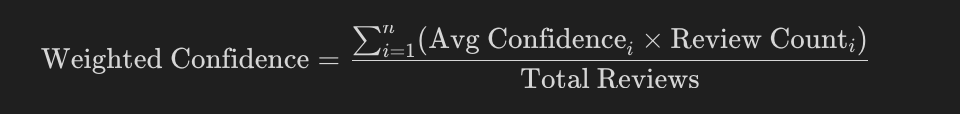

## 1. Set as 6 topics distribution

Discovered Topics:
Topic 0: american, traditional, new, breakfast, brunch, restaurants, diners, burgers, seafood, sandwiches
Topic 1: coffee, tea, food, donuts, cafes, bakeries, brunch, breakfast, restaurants, bagels
Topic 2: pizza, italian, restaurants, sandwiches, wings, chicken, salad, cheesesteaks, delis, seafood
Topic 3: food, fast, burgers, sandwiches, restaurants, grocery, ice, cream, yogurt, frozen
Topic 4: bars, nightlife, wine, sports, beer, sushi, cocktail, pubs, japanese, spirits
Topic 5: mexican, restaurants, chinese, tacos, tex, mex, seafood, japanese, brunch, breakfast


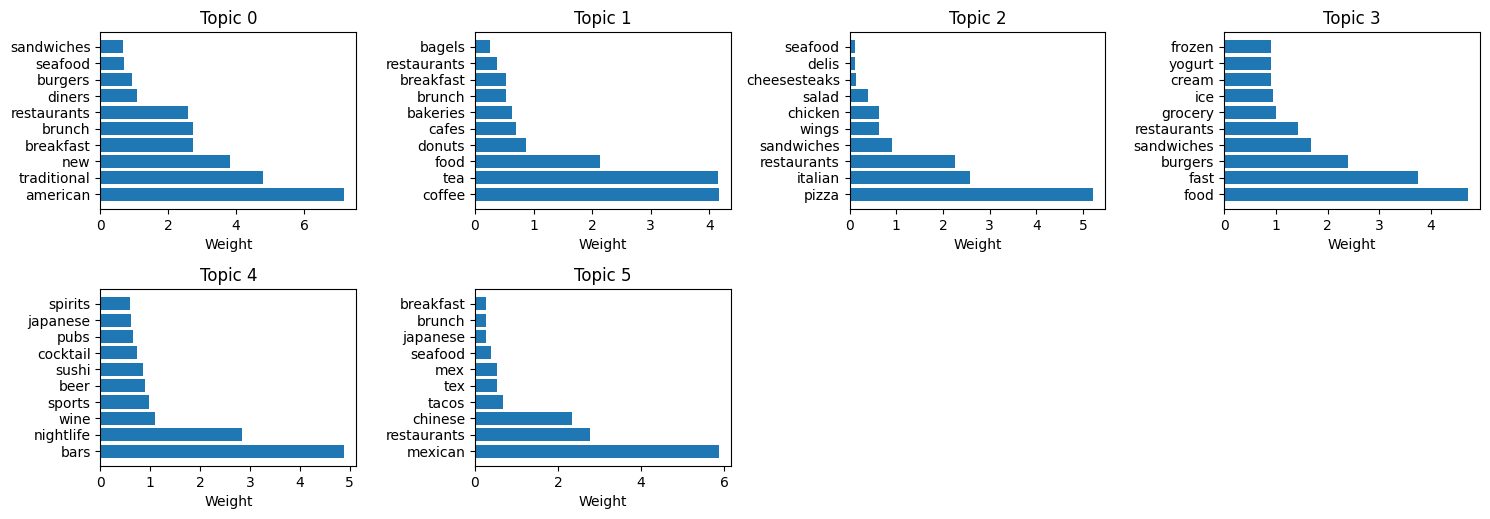

=== Topic Analysis ===


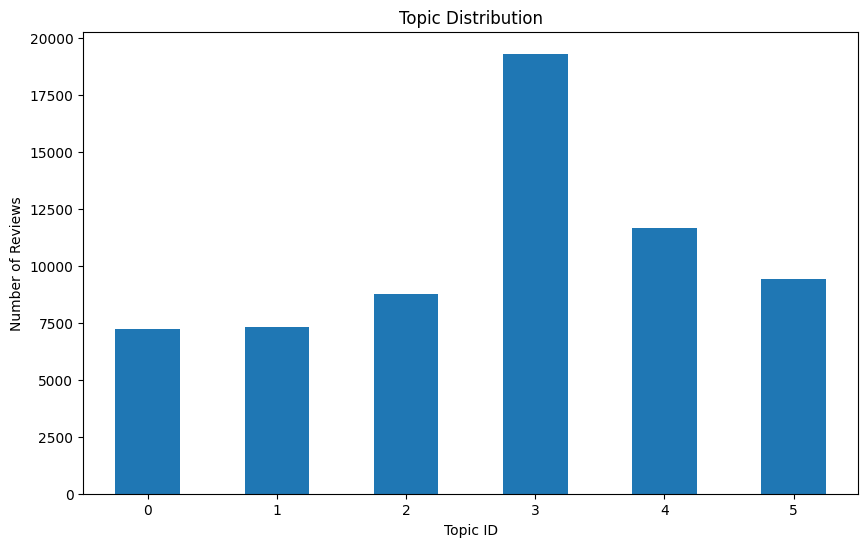

Topic distribution:
Topic 0: 7224 reviews (avg confidence: 0.047)
Topic 1: 7326 reviews (avg confidence: 0.089)
Topic 2: 8788 reviews (avg confidence: 0.084)
Topic 3: 19322 reviews (avg confidence: 0.042)
Topic 4: 11657 reviews (avg confidence: 0.069)
Topic 5: 9417 reviews (avg confidence: 0.053)
overall_weighted_confidence_across_all_clusters 0.0602

=== Topic-Star Rating Relationship ===
Analyzing 63734 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:135: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


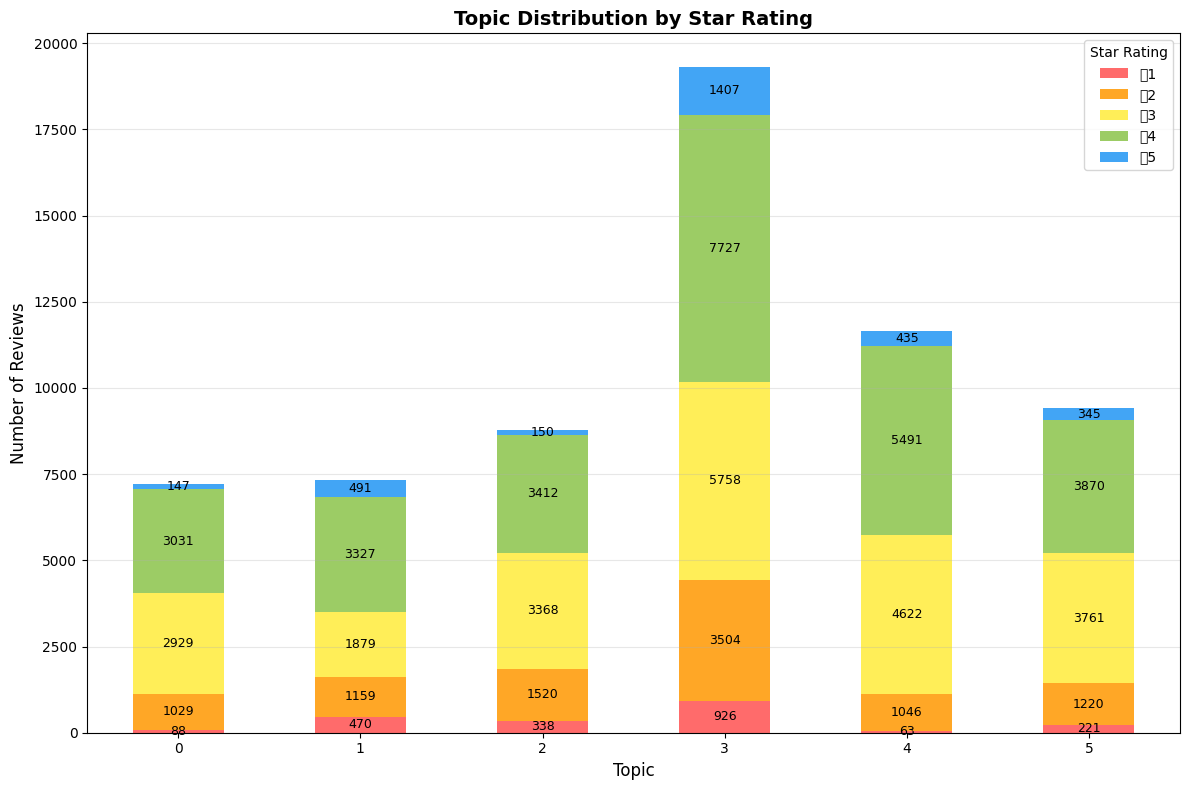


=== Topic Analysis Summary ===
Topic 0: 3.29 ± 0.78 stars (7224 reviews)
Topic 1: 3.30 ± 1.02 stars (7326 reviews)
Topic 2: 3.17 ± 0.87 stars (8788 reviews)
Topic 3: 3.27 ± 1.00 stars (19322 reviews)
Topic 4: 3.45 ± 0.73 stars (11657 reviews)
Topic 5: 3.31 ± 0.83 stars (9417 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:176: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


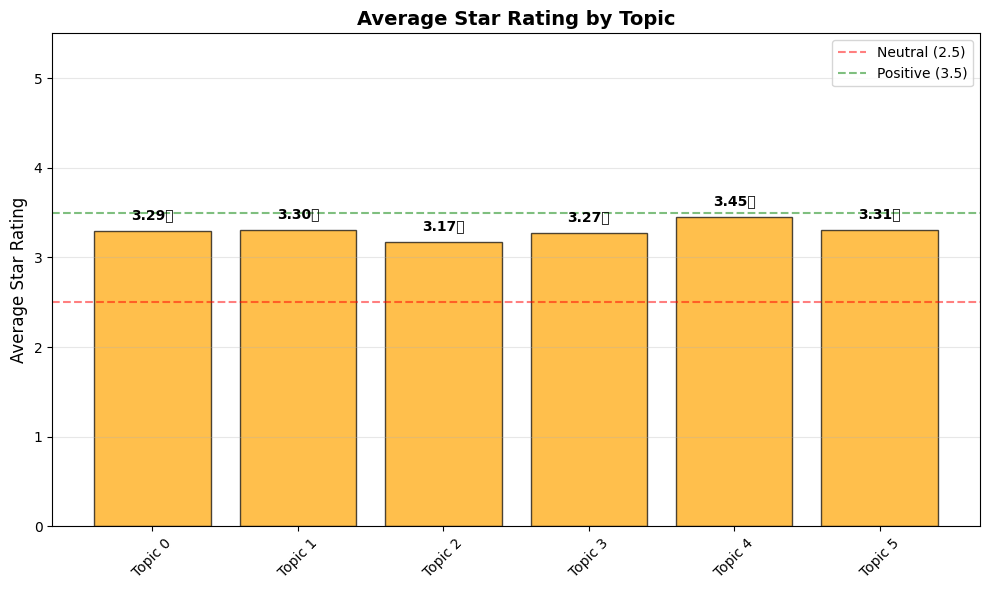

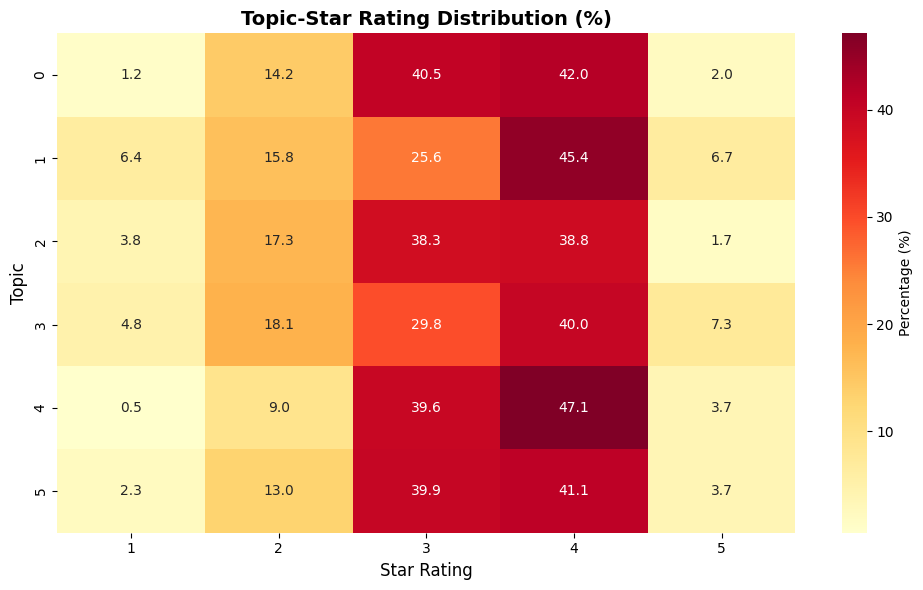

(                   business_id                           name  \
 0       Pns2l4eNsfO8kk83dixA6A       Abby Rappoport, LAC, CMQ   
 3       MTSW4McQd7CbVtyjqoe9mw             St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA       Perkiomen Valley Brewery   
 5       CF33F8-E6oudUQ46HnavjQ                 Sonic Drive-In   
 8       k0hlBqXX-Bt0vf1op7Jr1w          Tsevi's Pub And Grill   
 ...                        ...                            ...   
 150325  l9eLGG9ZKpLJzboZq-9LRQ                           Wawa   
 150327  cM6V90ExQD6KMSU3rRB5ZA              Dutch Bros Coffee   
 150328  1jx1sfgjgVg0nM6n3p0xWA           Savaya Coffee Market   
 150336  WnT9NIzQgLlILjPT0kEcsQ  Adelita Taqueria & Restaurant   
 150339  2O2K6SXPWv56amqxCECd4w                   The Plum Pit   
 
                        address             city state postal_code   latitude  \
 0       1616 Chapala St, Ste 2    Santa Barbara    CA       93101  34.426679   
 3                  935 Race St     Philadel

In [18]:
comprehensive_topic_analysis(filtered_data, n_topics=6)

In [31]:
# map dominant topic to categories
df_clusteredBIZ = df_topics.copy()
df_clusteredBIZ['topic_category'] = df_clusteredBIZ['topic'].map({0: 'Food & Dining',
                                 1: 'Health & Medical',
                                 2: 'Shopping',
                                 3: 'Automotive',
                                 4: 'Home Services',
                                 5: 'Beauty & Spas'})       
df_clusteredBIZ.head(2)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday,topic,topic_category
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN,0,Food & Dining
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0,2,Shopping


## 2. Set 8 clusters

Discovered Topics:
Topic 0: american, traditional, new, breakfast, brunch, restaurants, diners, burgers, seafood, cafes
Topic 1: coffee, tea, food, donuts, cafes, bakeries, brunch, breakfast, restaurants, desserts
Topic 2: pizza, italian, restaurants, sandwiches, wings, chicken, salad, cheesesteaks, seafood, services
Topic 3: food, fast, burgers, sandwiches, restaurants, grocery, delis, specialty, chicken, services
Topic 4: bars, nightlife, wine, sports, beer, sushi, cocktail, pubs, spirits, japanese
Topic 5: mexican, restaurants, tacos, mex, tex, brunch, breakfast, seafood, latin, trucks
Topic 6: chinese, restaurants, japanese, asian, fusion, seafood, sushi, thai, vietnamese, buffets
Topic 7: ice, yogurt, frozen, cream, food, desserts, bakeries, shaved, juice, smoothies


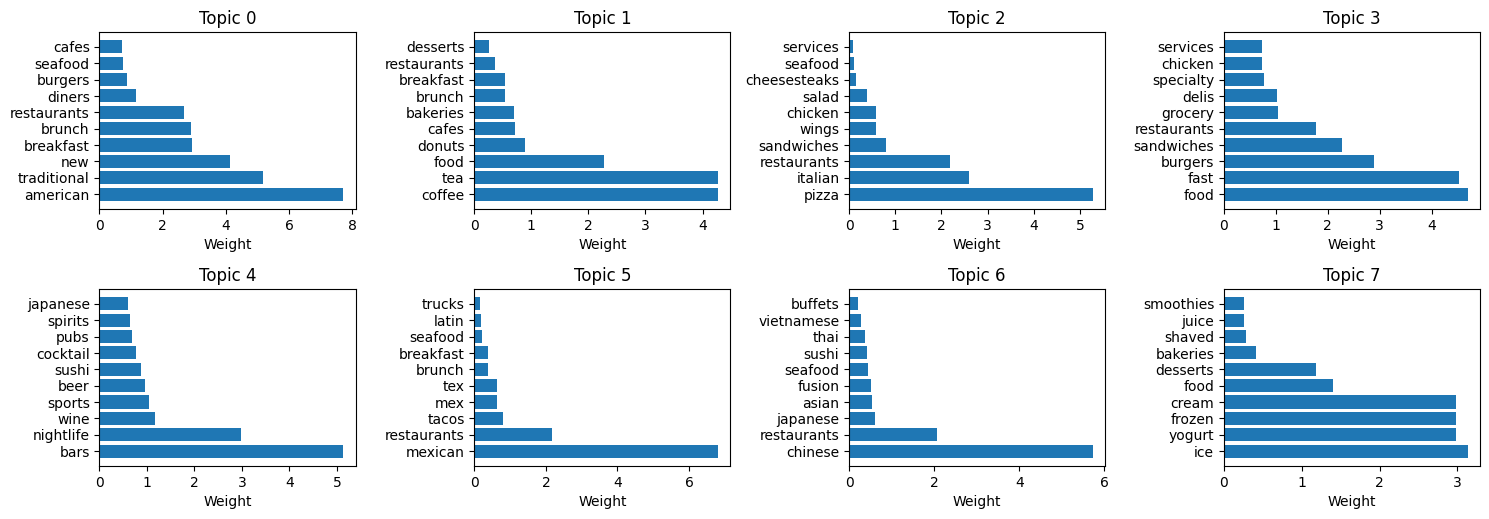

=== Topic Analysis ===


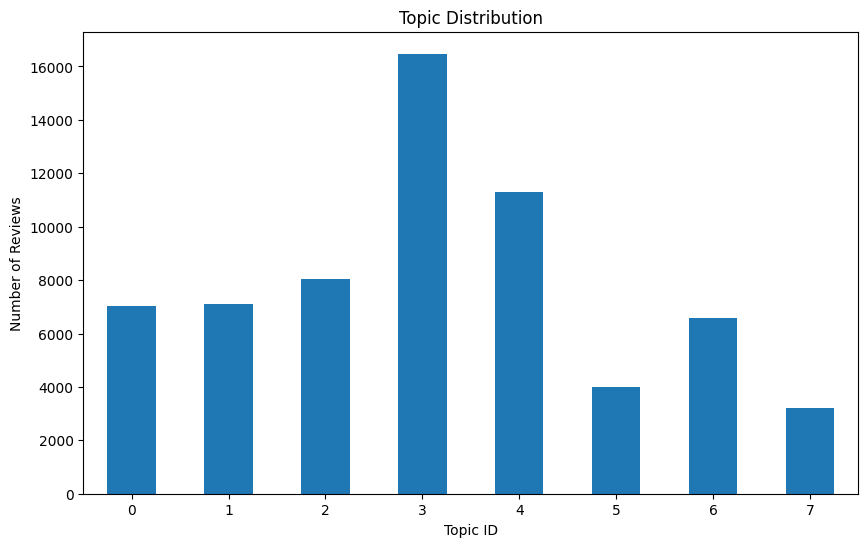

Topic distribution:
Topic 0: 7032 reviews (avg confidence: 0.044)
Topic 1: 7111 reviews (avg confidence: 0.087)
Topic 2: 8046 reviews (avg confidence: 0.089)
Topic 3: 16478 reviews (avg confidence: 0.037)
Topic 4: 11289 reviews (avg confidence: 0.066)
Topic 5: 3984 reviews (avg confidence: 0.091)
Topic 6: 6594 reviews (avg confidence: 0.062)
Topic 7: 3200 reviews (avg confidence: 0.108)
overall_weighted_confidence_across_all_clusters 0.0647

=== Topic-Star Rating Relationship ===
Analyzing 63734 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:135: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


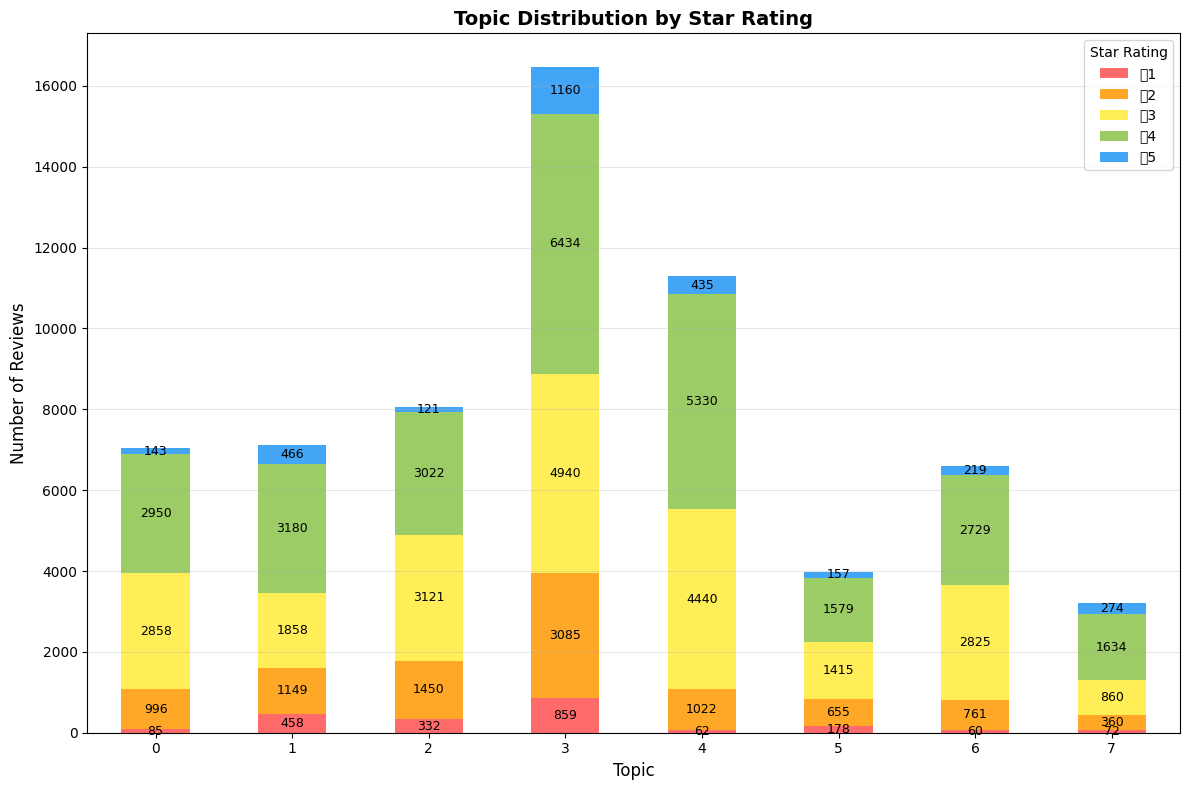


=== Topic Analysis Summary ===
Topic 0: 3.29 ± 0.78 stars (7032 reviews)
Topic 1: 3.29 ± 1.02 stars (7111 reviews)
Topic 2: 3.14 ± 0.87 stars (8046 reviews)
Topic 3: 3.24 ± 1.01 stars (16478 reviews)
Topic 4: 3.45 ± 0.73 stars (11289 reviews)
Topic 5: 3.22 ± 0.92 stars (3984 reviews)
Topic 6: 3.35 ± 0.76 stars (6594 reviews)
Topic 7: 3.52 ± 0.88 stars (3200 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:176: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


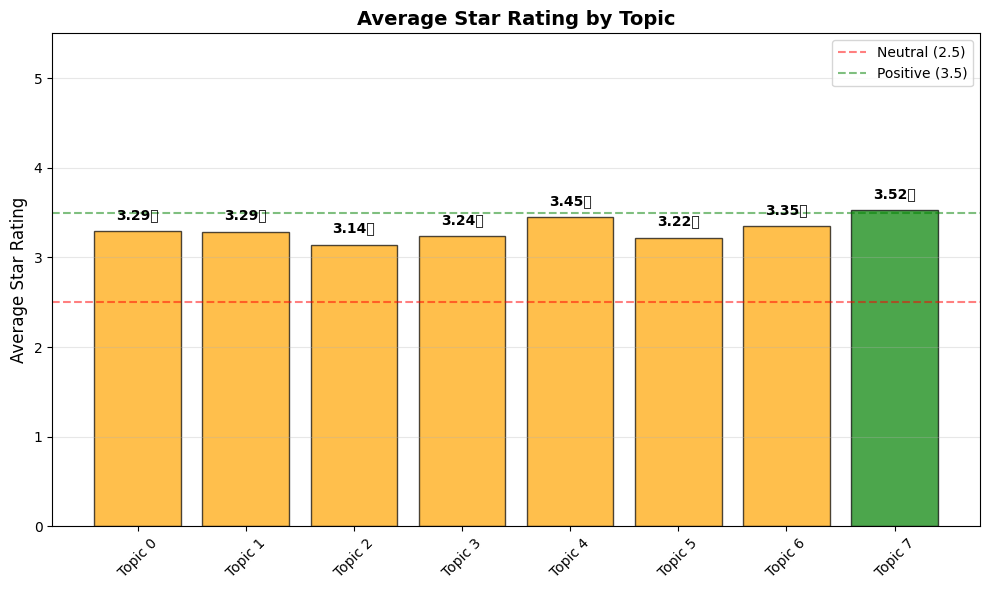

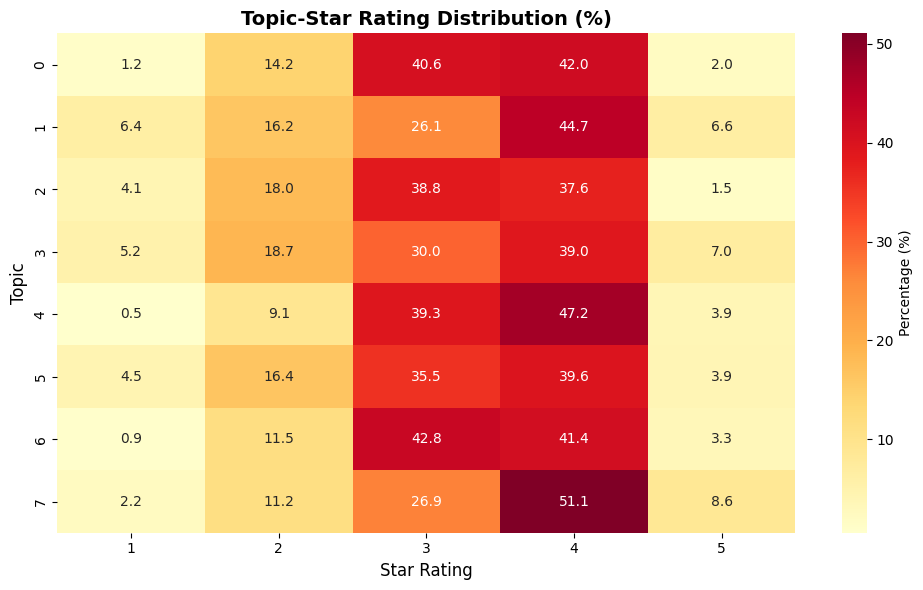

(                   business_id                           name  \
 0       Pns2l4eNsfO8kk83dixA6A       Abby Rappoport, LAC, CMQ   
 3       MTSW4McQd7CbVtyjqoe9mw             St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA       Perkiomen Valley Brewery   
 5       CF33F8-E6oudUQ46HnavjQ                 Sonic Drive-In   
 8       k0hlBqXX-Bt0vf1op7Jr1w          Tsevi's Pub And Grill   
 ...                        ...                            ...   
 150325  l9eLGG9ZKpLJzboZq-9LRQ                           Wawa   
 150327  cM6V90ExQD6KMSU3rRB5ZA              Dutch Bros Coffee   
 150328  1jx1sfgjgVg0nM6n3p0xWA           Savaya Coffee Market   
 150336  WnT9NIzQgLlILjPT0kEcsQ  Adelita Taqueria & Restaurant   
 150339  2O2K6SXPWv56amqxCECd4w                   The Plum Pit   
 
                        address             city state postal_code   latitude  \
 0       1616 Chapala St, Ste 2    Santa Barbara    CA       93101  34.426679   
 3                  935 Race St     Philadel

In [19]:
comprehensive_topic_analysis(filtered_data, n_topics=8)

## 3. Set 12 clusters

Discovered Topics:
Topic 0: american, traditional, new, restaurants, seafood, burgers, steakhouses, nightlife, diners, barbeque
Topic 1: coffee, tea, food, donuts, cafes, bakeries, restaurants, roasteries, juice, smoothies
Topic 2: pizza, italian, restaurants, wings, chicken, salad, cheesesteaks, delivery, seafood, gluten
Topic 3: fast, burgers, food, restaurants, chicken, wings, dogs, hot, shop, tacos
Topic 4: bars, nightlife, sports, wine, sushi, beer, cocktail, pubs, japanese, spirits
Topic 5: mexican, restaurants, tacos, tex, mex, seafood, latin, trucks, food, fast
Topic 6: chinese, restaurants, japanese, asian, fusion, seafood, sushi, thai, vietnamese, buffets
Topic 7: ice, frozen, yogurt, cream, food, desserts, shaved, smoothies, juice, bakeries
Topic 8: food, grocery, specialty, bakeries, stores, shopping, spirits, beer, wine, shops
Topic 9: sandwiches, delis, restaurants, salad, chicken, wings, soup, fast, cheesesteaks, barbeque
Topic 10: event, planning, services, caterers, ve

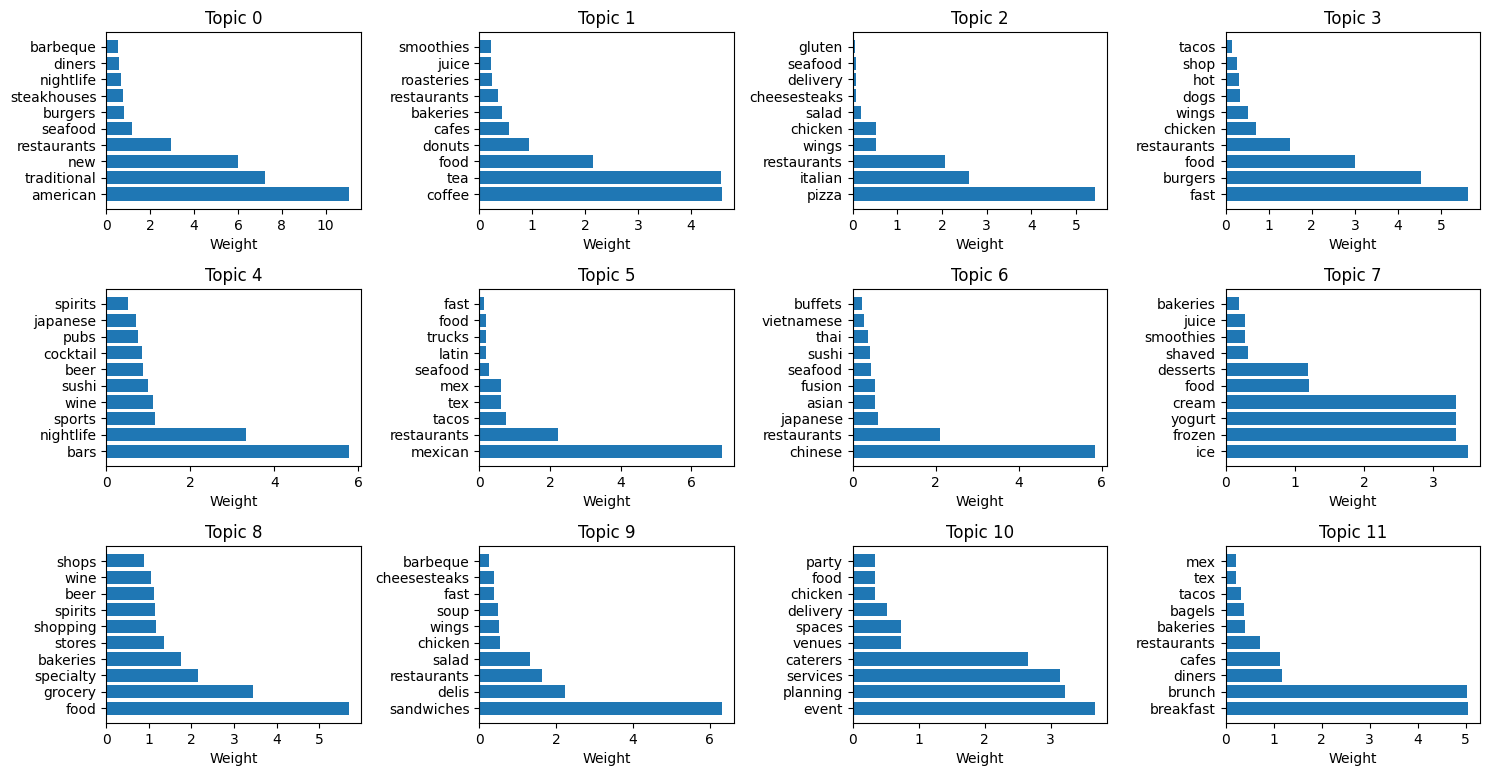

=== Topic Analysis ===


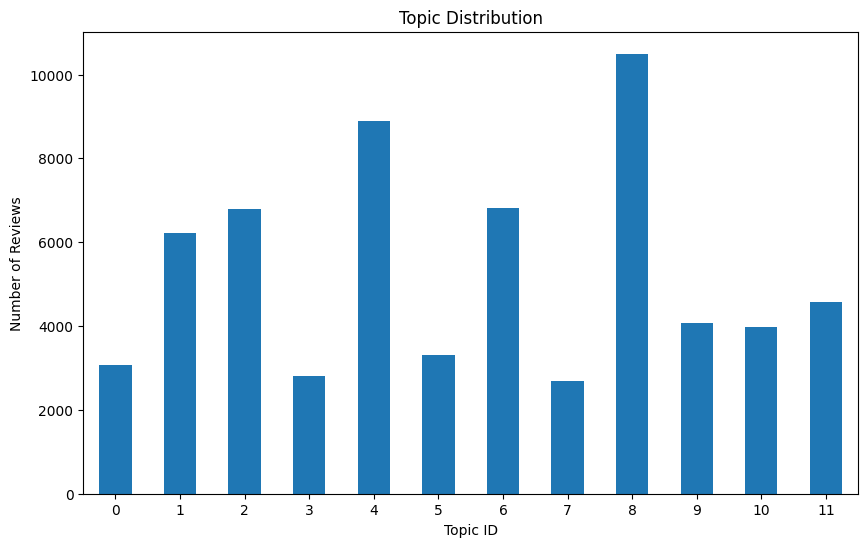

Topic distribution:
Topic 0: 3062 reviews (avg confidence: 0.041)
Topic 1: 6211 reviews (avg confidence: 0.090)
Topic 2: 6803 reviews (avg confidence: 0.098)
Topic 3: 2818 reviews (avg confidence: 0.076)
Topic 4: 8897 reviews (avg confidence: 0.066)
Topic 5: 3315 reviews (avg confidence: 0.099)
Topic 6: 6805 reviews (avg confidence: 0.059)
Topic 7: 2680 reviews (avg confidence: 0.114)
Topic 8: 10497 reviews (avg confidence: 0.043)
Topic 9: 4083 reviews (avg confidence: 0.068)
Topic 10: 3980 reviews (avg confidence: 0.087)
Topic 11: 4583 reviews (avg confidence: 0.070)
overall_weighted_confidence_across_all_clusters 0.0718

=== Topic-Star Rating Relationship ===
Analyzing 63734 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:135: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


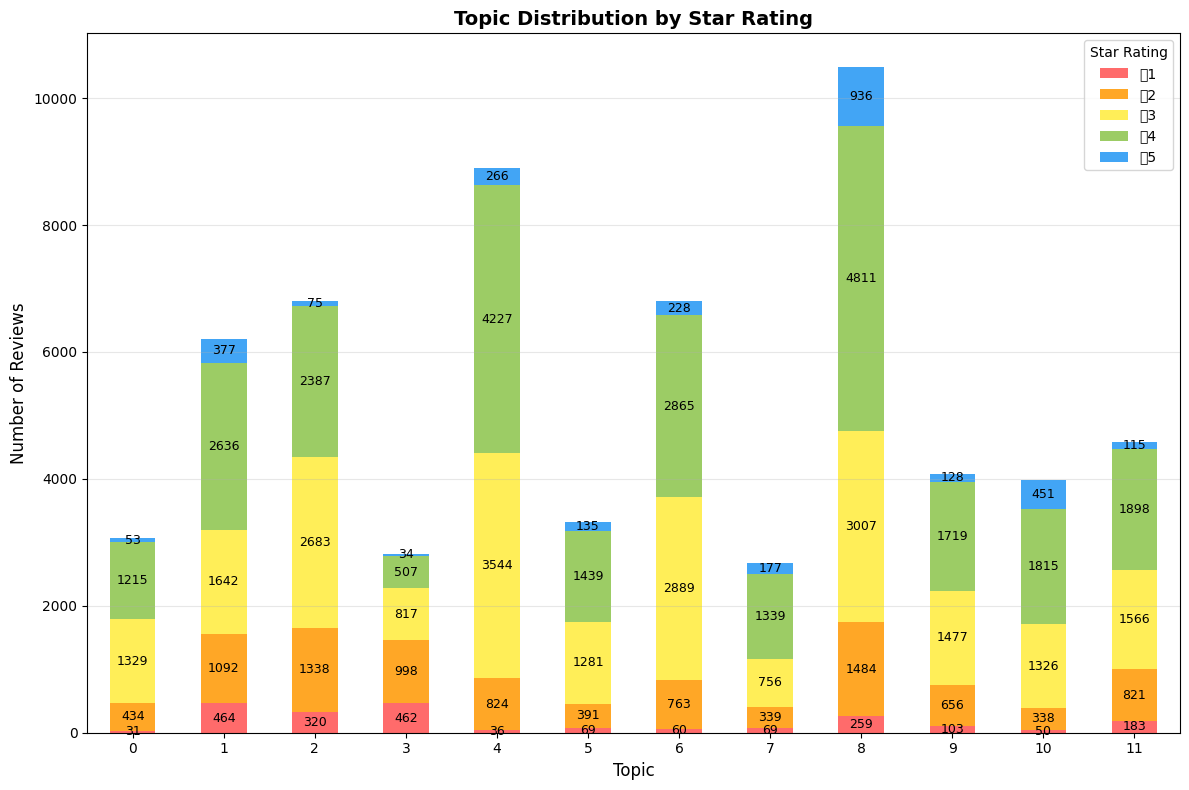

/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:176: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



=== Topic Analysis Summary ===
Topic 0: 3.27 ± 0.76 stars (3062 reviews)
Topic 1: 3.22 ± 1.05 stars (6211 reviews)
Topic 2: 3.08 ± 0.88 stars (6803 reviews)
Topic 3: 2.52 ± 1.00 stars (2818 reviews)
Topic 4: 3.43 ± 0.72 stars (8897 reviews)
Topic 5: 3.36 ± 0.82 stars (3315 reviews)
Topic 6: 3.36 ± 0.76 stars (6805 reviews)
Topic 7: 3.45 ± 0.89 stars (2680 reviews)
Topic 8: 3.45 ± 0.93 stars (10497 reviews)
Topic 9: 3.27 ± 0.86 stars (4083 reviews)
Topic 10: 3.57 ± 0.85 stars (3980 reviews)
Topic 11: 3.21 ± 0.90 stars (4583 reviews)


/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


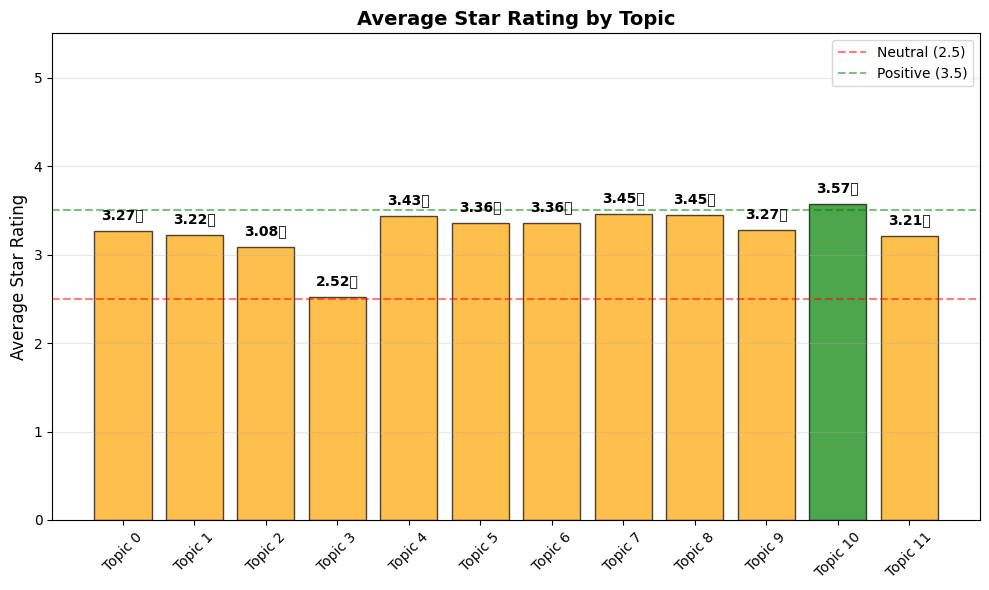

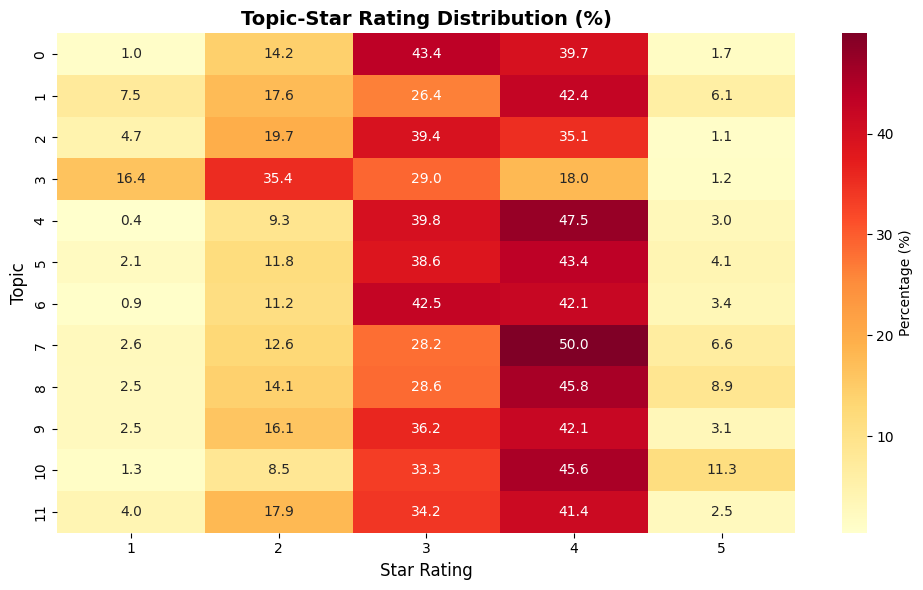

(                   business_id                           name  \
 0       Pns2l4eNsfO8kk83dixA6A       Abby Rappoport, LAC, CMQ   
 3       MTSW4McQd7CbVtyjqoe9mw             St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA       Perkiomen Valley Brewery   
 5       CF33F8-E6oudUQ46HnavjQ                 Sonic Drive-In   
 8       k0hlBqXX-Bt0vf1op7Jr1w          Tsevi's Pub And Grill   
 ...                        ...                            ...   
 150325  l9eLGG9ZKpLJzboZq-9LRQ                           Wawa   
 150327  cM6V90ExQD6KMSU3rRB5ZA              Dutch Bros Coffee   
 150328  1jx1sfgjgVg0nM6n3p0xWA           Savaya Coffee Market   
 150336  WnT9NIzQgLlILjPT0kEcsQ  Adelita Taqueria & Restaurant   
 150339  2O2K6SXPWv56amqxCECd4w                   The Plum Pit   
 
                        address             city state postal_code   latitude  \
 0       1616 Chapala St, Ste 2    Santa Barbara    CA       93101  34.426679   
 3                  935 Race St     Philadel

In [22]:
comprehensive_topic_analysis(filtered_data, n_topics=12)

## 4. Set as 15 clusters 

Discovered Topics:
Topic 0: american, traditional, new, restaurants, seafood, burgers, steakhouses, nightlife, diners, barbeque
Topic 1: coffee, tea, food, donuts, cafes, bakeries, restaurants, roasteries, bubble, juice
Topic 2: pizza, restaurants, salad, cheesesteaks, delivery, free, gluten, wings, food, services
Topic 3: fast, burgers, food, restaurants, dogs, hot, tacos, mex, tex, shop
Topic 4: bars, nightlife, sports, sushi, cocktail, japanese, pubs, restaurants, juice, smoothies
Topic 5: mexican, restaurants, tacos, tex, mex, seafood, latin, trucks, food, fast
Topic 6: chinese, restaurants, japanese, asian, fusion, seafood, sushi, thai, vietnamese, buffets
Topic 7: ice, frozen, yogurt, cream, desserts, food, shaved, smoothies, juice, bakeries
Topic 8: food, grocery, specialty, bakeries, stores, shopping, shops, convenience, desserts, drugstores
Topic 9: sandwiches, delis, restaurants, salad, soup, fast, cheesesteaks, bagels, barbeque, food
Topic 10: event, planning, services, cate

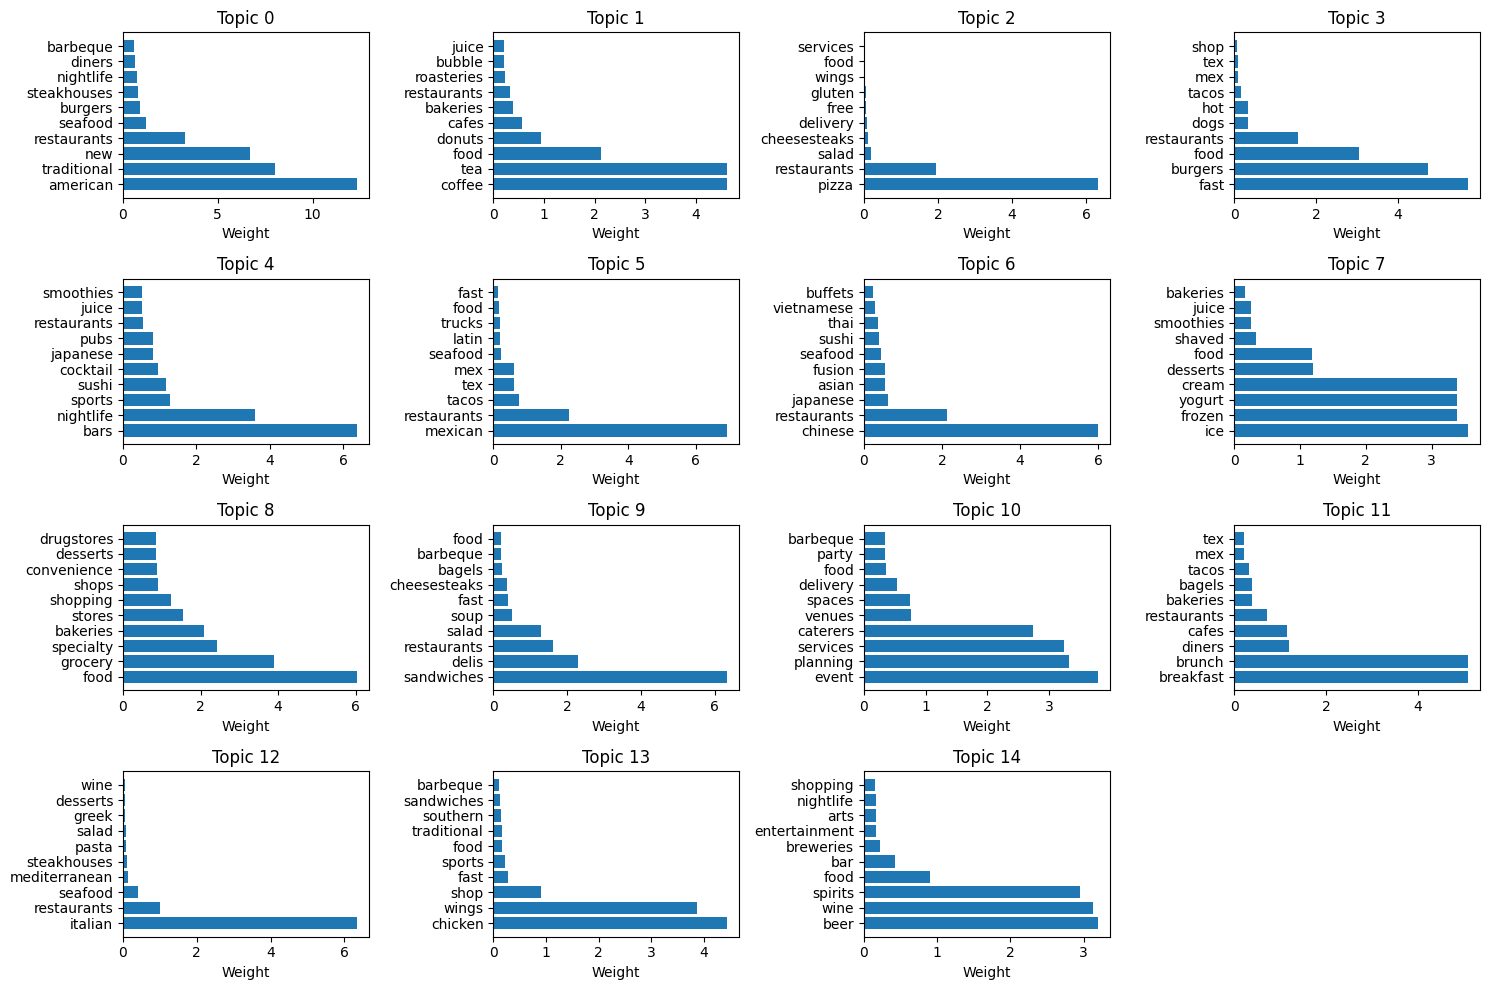

=== Topic Analysis ===


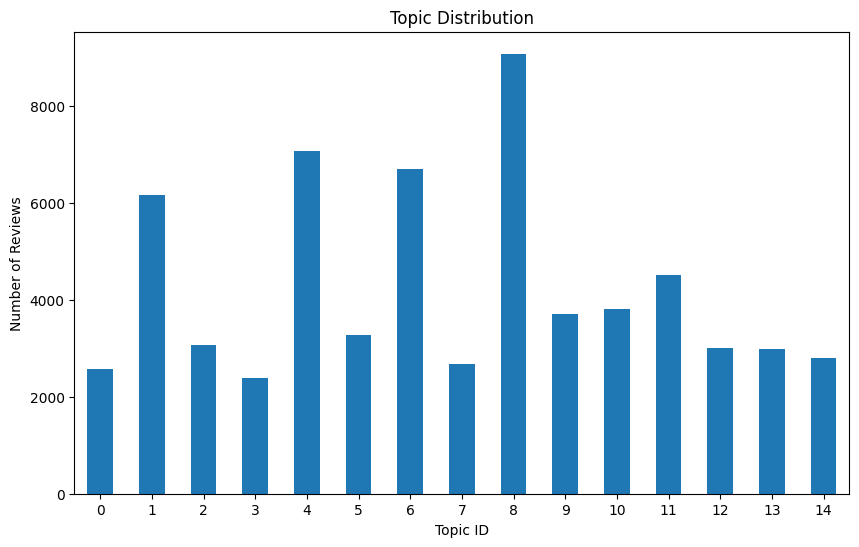

Topic distribution:
Topic 0: 2576 reviews (avg confidence: 0.037)
Topic 1: 6153 reviews (avg confidence: 0.090)
Topic 2: 3069 reviews (avg confidence: 0.118)
Topic 3: 2381 reviews (avg confidence: 0.080)
Topic 4: 7058 reviews (avg confidence: 0.062)
Topic 5: 3278 reviews (avg confidence: 0.098)
Topic 6: 6695 reviews (avg confidence: 0.058)
Topic 7: 2666 reviews (avg confidence: 0.112)
Topic 8: 9067 reviews (avg confidence: 0.041)
Topic 9: 3702 reviews (avg confidence: 0.068)
Topic 10: 3811 reviews (avg confidence: 0.085)
Topic 11: 4499 reviews (avg confidence: 0.070)
Topic 12: 3006 reviews (avg confidence: 0.101)
Topic 13: 2977 reviews (avg confidence: 0.106)
Topic 14: 2796 reviews (avg confidence: 0.108)
overall_weighted_confidence_across_all_clusters 0.0757

=== Topic-Star Rating Relationship ===
Analyzing 63734 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:135: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


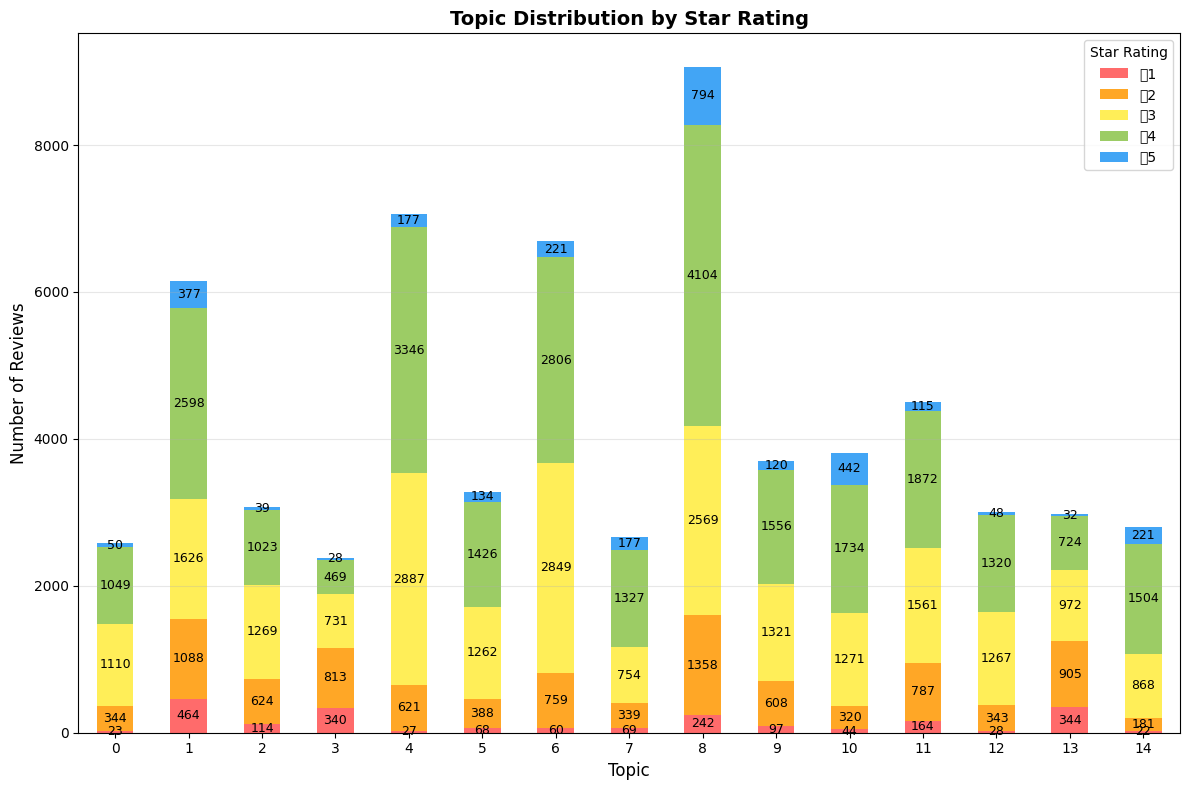


=== Topic Analysis Summary ===
Topic 0: 3.29 ± 0.75 stars (2576 reviews)
Topic 1: 3.22 ± 1.05 stars (6153 reviews)
Topic 2: 3.08 ± 0.85 stars (3069 reviews)
Topic 3: 2.59 ± 1.00 stars (2381 reviews)
Topic 4: 3.43 ± 0.70 stars (7058 reviews)
Topic 5: 3.36 ± 0.82 stars (3278 reviews)
Topic 6: 3.35 ± 0.76 stars (6695 reviews)
Topic 7: 3.45 ± 0.89 stars (2666 reviews)
Topic 8: 3.42 ± 0.94 stars (9067 reviews)
Topic 9: 3.27 ± 0.86 stars (3702 reviews)
Topic 10: 3.58 ± 0.84 stars (3811 reviews)
Topic 11: 3.22 ± 0.89 stars (4499 reviews)
Topic 12: 3.34 ± 0.73 stars (3006 reviews)
Topic 13: 2.73 ± 0.99 stars (2977 reviews)
Topic 14: 3.62 ± 0.76 stars (2796 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/970793395.py:176: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


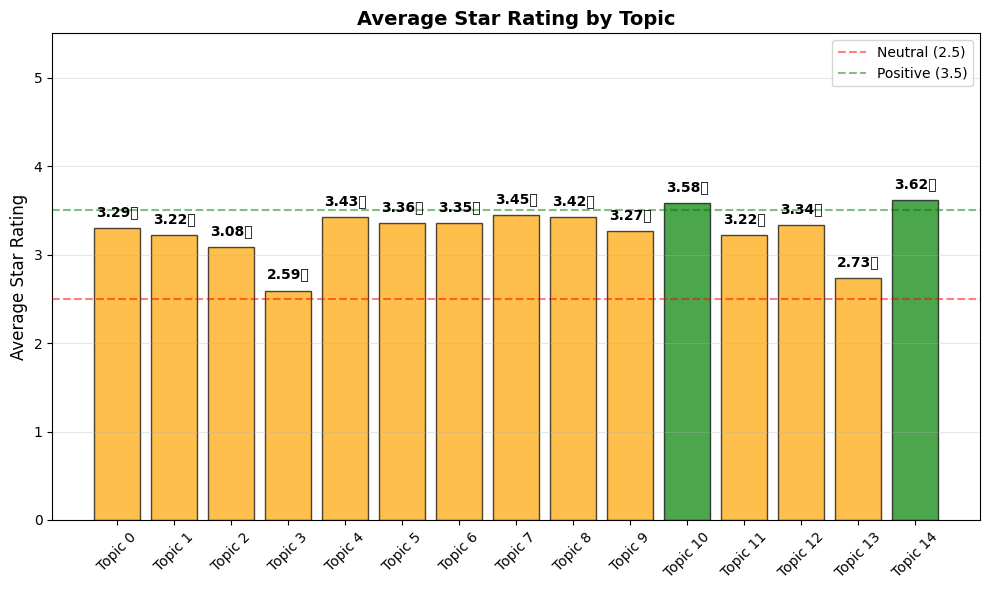

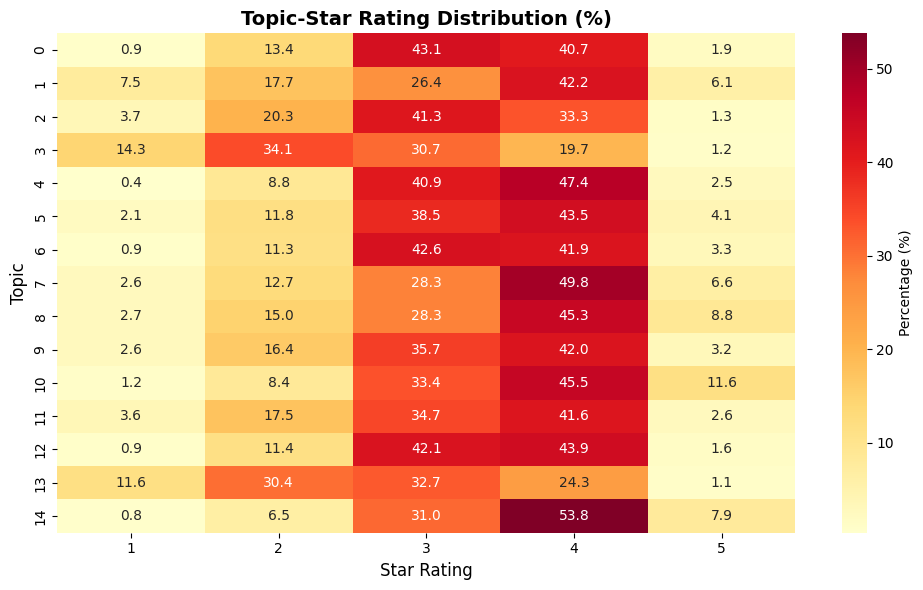

DataFrame shape: (63734, 60)
NMF model components: (15, 819)
TF-IDF features: 819
TOpic list for each cluster: [['american', 'traditional', 'new', 'restaurants', 'seafood', 'burgers', 'steakhouses', 'nightlife', 'diners', 'barbeque'], ['coffee', 'tea', 'food', 'donuts', 'cafes', 'bakeries', 'restaurants', 'roasteries', 'bubble', 'juice'], ['pizza', 'restaurants', 'salad', 'cheesesteaks', 'delivery', 'free', 'gluten', 'wings', 'food', 'services'], ['fast', 'burgers', 'food', 'restaurants', 'dogs', 'hot', 'tacos', 'mex', 'tex', 'shop'], ['bars', 'nightlife', 'sports', 'sushi', 'cocktail', 'japanese', 'pubs', 'restaurants', 'juice', 'smoothies'], ['mexican', 'restaurants', 'tacos', 'tex', 'mex', 'seafood', 'latin', 'trucks', 'food', 'fast'], ['chinese', 'restaurants', 'japanese', 'asian', 'fusion', 'seafood', 'sushi', 'thai', 'vietnamese', 'buffets'], ['ice', 'frozen', 'yogurt', 'cream', 'desserts', 'food', 'shaved', 'smoothies', 'juice', 'bakeries'], ['food', 'grocery', 'specialty', 'bak

In [21]:
df_with_topics, nmf_model, tfidf_vectorizer, topics_clusters_list = comprehensive_topic_analysis(filtered_data, text_column='categories', n_topics=15)

# Now you can access these variables in subsequent cells
print("DataFrame shape:", df_with_topics.shape)
print("NMF model components:", nmf_model.components_.shape)
print("TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))
print("TOpic list for each cluster:", topics_clusters_list)

In [121]:
len(topics_clusters_list)

15

## 5. COnfidence Score Comparison

In [106]:
all_results = {
    'Result 1 (6 topics)': {
        0: (17138, 0.049), 1: (20614, 0.049), 2: (54039, 0.027),
        3: (27138, 0.055), 4: (10868, 0.071), 5: (20446, 0.058)
    },
    'Result 2 (8 topics)': {
        0: (16352, 0.049), 1: (12309, 0.073), 2: (36545, 0.029),
        3: (26153, 0.056), 4: (10421, 0.071), 5: (20306, 0.058),
        6: (12267, 0.064), 7: (15890, 0.049)
    },
    'Result 3 (15 topics)': {
        0: (7860, 0.048), 1: (11750, 0.074), 2: (15950, 0.033),
        3: (18324, 0.059), 4: (9857, 0.073), 5: (8449, 0.090),
        6: (9530, 0.076), 7: (10045, 0.063), 8: (10744, 0.073),
        9: (15457, 0.054), 10: (3602, 0.101), 11: (10974, 0.048),
        12: (5950, 0.085), 13: (8250, 0.061), 14: (3501, 0.112)
    },
    'Result 4 (12 topics)': {
        0: (8442, 0.051), 1: (11796, 0.074), 2: (19006, 0.036),
        3: (22048, 0.060), 4: (10454, 0.071), 5: (8597, 0.091),
        6: (10753, 0.070), 7: (14481, 0.049), 8: (10568, 0.074),
        9: (17922, 0.051), 10: (3657, 0.106), 11: (12519, 0.058)
    }
}

def analyze_results(results):
    """Comprehensive analysis of topic modeling results"""
    
    analysis = {}
    
    for result_name, topics in results.items():
        confidences = [conf for _, conf in topics.values()]
        counts = [count for count, _ in topics.values()]
        
        analysis[result_name] = {
            'num_topics': len(topics),
            'avg_confidence': np.mean(confidences),
            'median_confidence': np.median(confidences),
            'max_confidence': max(confidences),
            'min_confidence': min(confidences),
            'confidence_std': np.std(confidences),
            'avg_topic_size': np.mean(counts),
            'size_std': np.std(counts),
            'high_confidence_topics': len([c for c in confidences if c > 0.07]),
            'low_confidence_topics': len([c for c in confidences if c < 0.04])
        }
    
    return analysis

# Perform analysis
analysis = analyze_results(all_results)

print("=== COMPREHENSIVE COMPARISON ===")
for result_name, stats in analysis.items():
    print(f"\n{result_name}:")
    print(f"  Topics: {stats['num_topics']}")
    print(f"  Avg Confidence: {stats['avg_confidence']:.3f}")
    print(f"  Max Confidence: {stats['max_confidence']:.3f}")
    print(f"  High Confidence Topics (>0.07): {stats['high_confidence_topics']}")
    print(f"  Topic Size Std: {stats['size_std']:.0f} (lower = better balanced)")

=== COMPREHENSIVE COMPARISON ===

Result 1 (6 topics):
  Topics: 6
  Avg Confidence: 0.051
  Max Confidence: 0.071
  High Confidence Topics (>0.07): 1
  Topic Size Std: 13840 (lower = better balanced)

Result 2 (8 topics):
  Topics: 8
  Avg Confidence: 0.056
  Max Confidence: 0.073
  High Confidence Topics (>0.07): 2
  Topic Size Std: 8221 (lower = better balanced)

Result 3 (15 topics):
  Topics: 15
  Avg Confidence: 0.070
  Max Confidence: 0.112
  High Confidence Topics (>0.07): 8
  Topic Size Std: 4073 (lower = better balanced)

Result 4 (12 topics):
  Topics: 12
  Avg Confidence: 0.066
  Max Confidence: 0.106
  High Confidence Topics (>0.07): 5
  Topic Size Std: 4900 (lower = better balanced)


## 6. output biz dataset with new 15 clusters 

In [ ]:
## check output dataset has 15 clusters 
df_with_topics['dominant_topic'].value_counts().sort_index(ascending=True)

dominant_topic
0      7860
1     11750
2     15950
3     18324
4      9857
5      8449
6      9530
7     10045
8     10744
9     15457
10     3602
11    10974
12     5950
13     8250
14     3501
Name: count, dtype: int64

In [117]:
nmf_model

,n_components,15
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,1000
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [123]:
topics_clusters_list[2]

['services',
 'home',
 'local',
 'cleaning',
 'laundry',
 'repair',
 'contractors',
 'professional',
 'movers',
 'dry']

In [125]:
df_with_topics['dominant_topic']

0          7
1          2
2          9
3         12
4          3
          ..
150341     1
150342     9
150343     9
150344     9
150345     1
Name: dominant_topic, Length: 150243, dtype: int64

In [129]:
topic_words_dict = dict(enumerate(topics_clusters_list))
print(topic_words_dict)

{0: ['bars', 'nightlife', 'sports', 'pubs', 'wine', 'cocktail', 'beer', 'sushi', 'lounges', 'entertainment'], 1: ['spas', 'beauty', 'salons', 'hair', 'nail', 'removal', 'barbers', 'waxing', 'day', 'massage'], 2: ['services', 'home', 'local', 'cleaning', 'laundry', 'repair', 'contractors', 'professional', 'movers', 'dry'], 3: ['food', 'fast', 'burgers', 'grocery', 'sandwiches', 'restaurants', 'specialty', 'ice', 'frozen', 'yogurt'], 4: ['auto', 'automotive', 'repair', 'stations', 'car', 'tires', 'change', 'oil', 'dealers', 'parts'], 5: ['pizza', 'restaurants', 'italian', 'sandwiches', 'chicken', 'wings', 'salad', 'delis', 'cheesesteaks', 'seafood'], 6: ['hotels', 'event', 'planning', 'travel', 'services', 'venues', 'spaces', 'caterers', 'party', 'rental'], 7: ['medical', 'health', 'dentists', 'doctors', 'dentistry', 'general', 'cosmetic', 'massage', 'centers', 'surgeons'], 8: ['american', 'traditional', 'new', 'restaurants', 'brunch', 'breakfast', 'burgers', 'diners', 'sandwiches', 'sea

In [130]:
# map dominant topic to categories
df_clusteredBIZ = df_with_topics.copy()
df_clusteredBIZ['dominant_topic_category'] = df_clusteredBIZ['dominant_topic'].map(topic_words_dict)
df_clusteredBIZ.head(2)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday,dominant_topic,topic_confidence,dominant_topic_category
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN,7,0.041784,"[medical, health, dentists, doctors, dentistry..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0,2,0.030561,"[services, home, local, cleaning, laundry, rep..."


In [131]:
df_clusteredBIZ.to_csv('clustered_bizdataset.csv', index=False)

# Refactored text processing 

In [33]:
"""
improvement done::
    remove words that appear in more than 70% of documents (high-frequency) 
"""

def comprehensive_topic_analysis(df, text_column='categories', n_topics=5):
    """Comprehensive topic modeling with visualization"""
    
    # Clean data
    df_clean = df.dropna(subset=[text_column]).copy()
    df_clean[text_column] = df_clean[text_column].astype(str)
    df_clean = df_clean[df_clean[text_column].str.strip() != '']
    
    # # Create TF-IDF matrix
    # tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=2, max_df=0.8)
    # tfidf_matrix = tfidf.fit_transform(df_clean[text_column])
    # feature_names = tfidf.get_feature_names_out()

    # Example: remove words that appear in more than 70% of documents (high-frequency)
    tfidf = TfidfVectorizer(max_features=1000, max_df=0.7, min_df=2, ngram_range=(1,2))
    tfidf_matrix = tfidf.fit_transform(df['categories'])
    feature_names = tfidf.get_feature_names_out()
    print("TF-IDF features (after removing high-frequency terms):", feature_names[:20])
    
    # Apply NMF
    nmf = NMF(n_components=n_topics, random_state=42, max_iter=1000)
    W = nmf.fit_transform(tfidf_matrix)  # Document-topic matrix
    topic_term_mat = nmf.components_  # Topic-term matrix
    
    # Assign topics
    df_clean['dominant_topic'] = W.argmax(axis=1)
    df_clean['topic_confidence'] = W.max(axis=1)
    
    # Analyze and visualize topics
    print("Discovered Topics:")
    top_words_list = []
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        top_words_list.append(top_words)
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    plot_topics(topic_term_mat, feature_names, n_top_words=10)
    analyze_topic_quality(df_clean, W)
    topic_star_analysis(df_clean)
    
    return df_clean, nmf, tfidf, top_words_list

def plot_topics(H, feature_names, n_top_words=10):
    """Display the top words for each topic"""
    fig, axes = plt.subplots(4, 4, figsize=(15, 10))
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(H):
        if topic_idx < len(axes):
            # Get top words for this topic
            top_features_ind = topic.argsort()[:-n_top_words-1:-1]
            top_features = [feature_names[i] for i in top_features_ind]
            weights = topic[top_features_ind]
            
            # Plot
            axes[topic_idx].barh(range(n_top_words), weights)
            axes[topic_idx].set_yticks(range(n_top_words))
            axes[topic_idx].set_yticklabels(top_features)
            axes[topic_idx].set_title(f'Topic {topic_idx}')
            axes[topic_idx].set_xlabel('Weight')
    
    # Hide empty subplots
    for i in range(len(H), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_topic_quality(df_clean, W):
    """Analyze topic distribution and quality"""
    print("=== Topic Analysis ===")
    topic_counts = df_clean['dominant_topic'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    topic_counts.plot(kind='bar')
    plt.title('Topic Distribution')
    plt.xlabel('Topic ID')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=0)
    plt.show()
    
    overall_weighted_confidence_across_all_clusters = 0
    print("Topic distribution:")
    for topic_id, count in topic_counts.items():
        avg_confidence = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].mean()
        review_count = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].count()
        overall_weighted_confidence_across_all_clusters += avg_confidence*review_count
        print(f"Topic {topic_id}: {count} reviews (avg confidence: {avg_confidence:.3f})")
    
    overall_weighted_confidence_across_all_clusters = overall_weighted_confidence_across_all_clusters/df_clean.shape[0]
    print(f"overall_weighted_confidence_across_all_clusters {overall_weighted_confidence_across_all_clusters:.4f}")


    return overall_weighted_confidence_across_all_clusters

def topic_star_analysis(df_clean):
    """Analyze relationship between topics and star ratings with integer stars"""
    if 'stars' in df_clean.columns:
        print("\n=== Topic-Star Rating Relationship ===")
        
        # Ensure stars are integers and filter only 1-5
        df_clean = df_clean.copy()
        df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
        df_clean = df_clean.dropna(subset=['stars'])
        df_clean['stars'] = df_clean['stars'].astype(int)
        df_clean = df_clean[df_clean['stars'].between(1, 5)]
        
        print(f"Analyzing {len(df_clean)} reviews with star ratings 1-5")
        
        # 1. Cross-tabulation with proper integer stars
        cross_tab = pd.crosstab(df_clean['dominant_topic'], df_clean['stars'])
        
        # Reindex to ensure all star ratings 1-5 are included
        all_stars = range(1, 6)
        cross_tab = cross_tab.reindex(columns=all_stars, fill_value=0)
        
        # Plot stacked bar chart
        plt.figure(figsize=(12, 8))
        ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), 
                           color=['#ff6b6b', '#ffa726', '#ffee58', '#9ccc65', '#42a5f5'])
        plt.title('Topic Distribution by Star Rating', fontsize=14, fontweight='bold')
        plt.xlabel('Topic', fontsize=12)
        plt.ylabel('Number of Reviews', fontsize=12)
        plt.legend(title='Star Rating', labels=[f'⭐{star}' for star in all_stars])
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, label_type='center', fmt='%d', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Topic sentiment analysis with integer stars
        topic_avg_rating = df_clean.groupby('dominant_topic')['stars'].mean()
        topic_rating_std = df_clean.groupby('dominant_topic')['stars'].std()
        topic_counts = df_clean.groupby('dominant_topic').size()
        
        print("\n=== Topic Analysis Summary ===")
        for topic in sorted(topic_avg_rating.index):
            avg_rating = topic_avg_rating[topic]
            std_rating = topic_rating_std[topic]
            count = topic_counts[topic]
            
            print(f"Topic {topic}: {avg_rating:.2f} ± {std_rating:.2f} stars ({count} reviews)")
        
        # 3. Plot average star rating by topic
        plt.figure(figsize=(10, 6))
        topics_sorted = sorted(topic_avg_rating.index)
        avg_ratings = [topic_avg_rating[topic] for topic in topics_sorted]
        colors = ['red' if rating < 2.5 else 'orange' if rating < 3.5 else 'green' for rating in avg_ratings]
        
        bars = plt.bar([f'Topic {topic}' for topic in topics_sorted], avg_ratings, 
                      color=colors, alpha=0.7, edgecolor='black')
        
        plt.title('Average Star Rating by Topic', fontsize=14, fontweight='bold')
        plt.ylabel('Average Star Rating', fontsize=12)
        plt.ylim(0, 5.5)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, rating in zip(bars, avg_ratings):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{rating:.2f}⭐', ha='center', va='bottom', fontweight='bold')
        
        # Add horizontal line at neutral rating (2.5)
        plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='Neutral (2.5)')
        plt.axhline(y=3.5, color='green', linestyle='--', alpha=0.5, label='Positive (3.5)')
        plt.legend()
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # 4. Heatmap of topic-star correlation
        plt.figure(figsize=(10, 6))
        
        # Calculate percentage distribution
        cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        
        sns.heatmap(cross_tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
                   cbar_kws={'label': 'Percentage (%)'})
        plt.title('Topic-Star Rating Distribution (%)', fontsize=14, fontweight='bold')
        plt.xlabel('Star Rating', fontsize=12)
        plt.ylabel('Topic', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        return {
            'cross_tab': cross_tab,
            'avg_ratings': topic_avg_rating,
            'topic_counts': topic_counts
        }



TF-IDF features (after removing high-frequency terms): ['acai' 'acai bowls' 'active' 'active life' 'activities' 'acupuncture'
 'african' 'american' 'american new' 'american restaurants'
 'american traditional' 'arcades' 'art' 'art galleries' 'arts'
 'arts crafts' 'arts entertainment' 'asian' 'asian fusion' 'auto']
Discovered Topics:
Topic 0: coffee, tea, coffee tea, food, food coffee, tea food, donuts, cafes, restaurants coffee, tea restaurants
Topic 1: american, bars, american traditional, traditional, new, american new, nightlife, restaurants american, breakfast, brunch
Topic 2: pizza, restaurants pizza, pizza restaurants, italian, italian restaurants, restaurants italian, pizza italian, italian pizza, sandwiches, chicken wings
Topic 3: food, fast food, fast, burgers, food restaurants, restaurants fast, sandwiches, restaurants burgers, food burgers, burgers restaurants
Topic 4: ice, ice cream, yogurt, frozen, frozen yogurt, cream, cream frozen, food ice, yogurt food, food
Topic 5: me

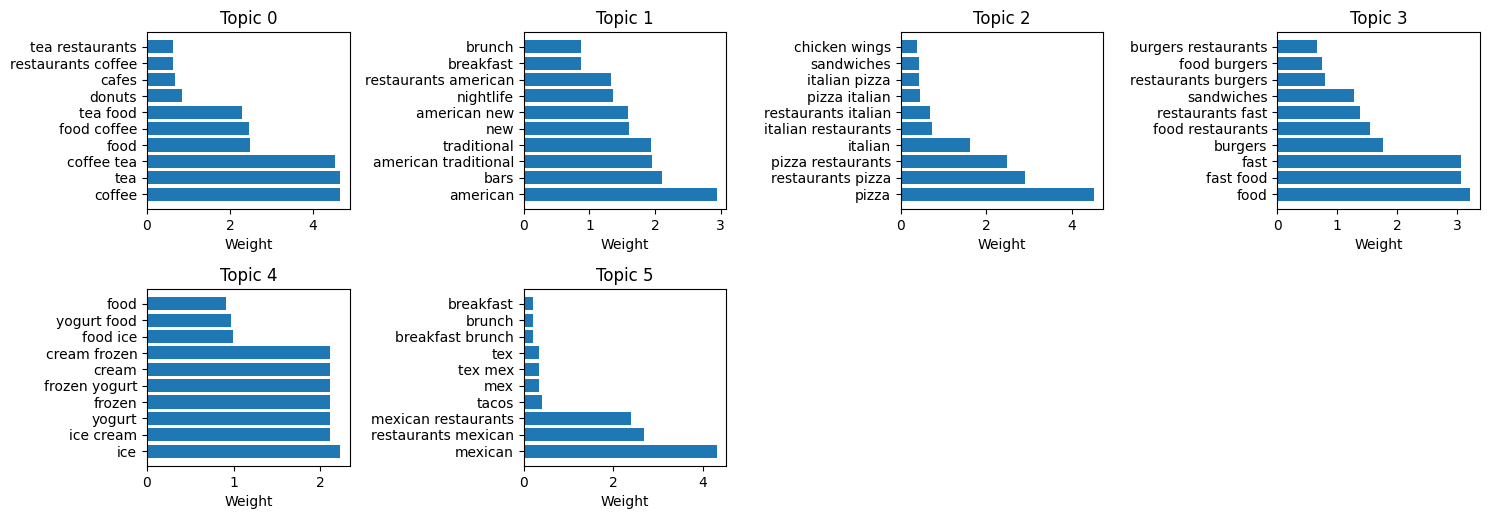

=== Topic Analysis ===


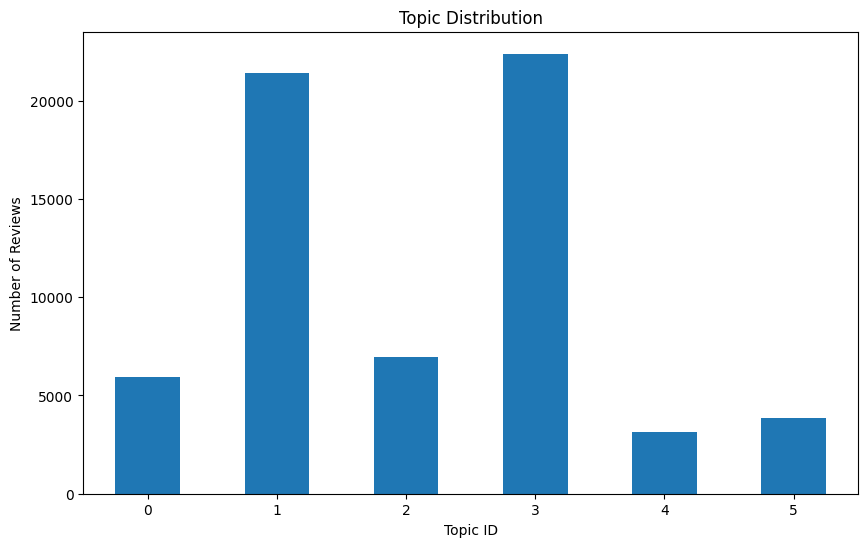

Topic distribution:
Topic 0: 5954 reviews (avg confidence: 0.052)
Topic 1: 21429 reviews (avg confidence: 0.042)
Topic 2: 6976 reviews (avg confidence: 0.071)
Topic 3: 22385 reviews (avg confidence: 0.029)
Topic 4: 3116 reviews (avg confidence: 0.104)
Topic 5: 3874 reviews (avg confidence: 0.090)
overall_weighted_confidence_across_all_clusters 0.0474

=== Topic-Star Rating Relationship ===
Analyzing 63734 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/2055396898.py:136: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


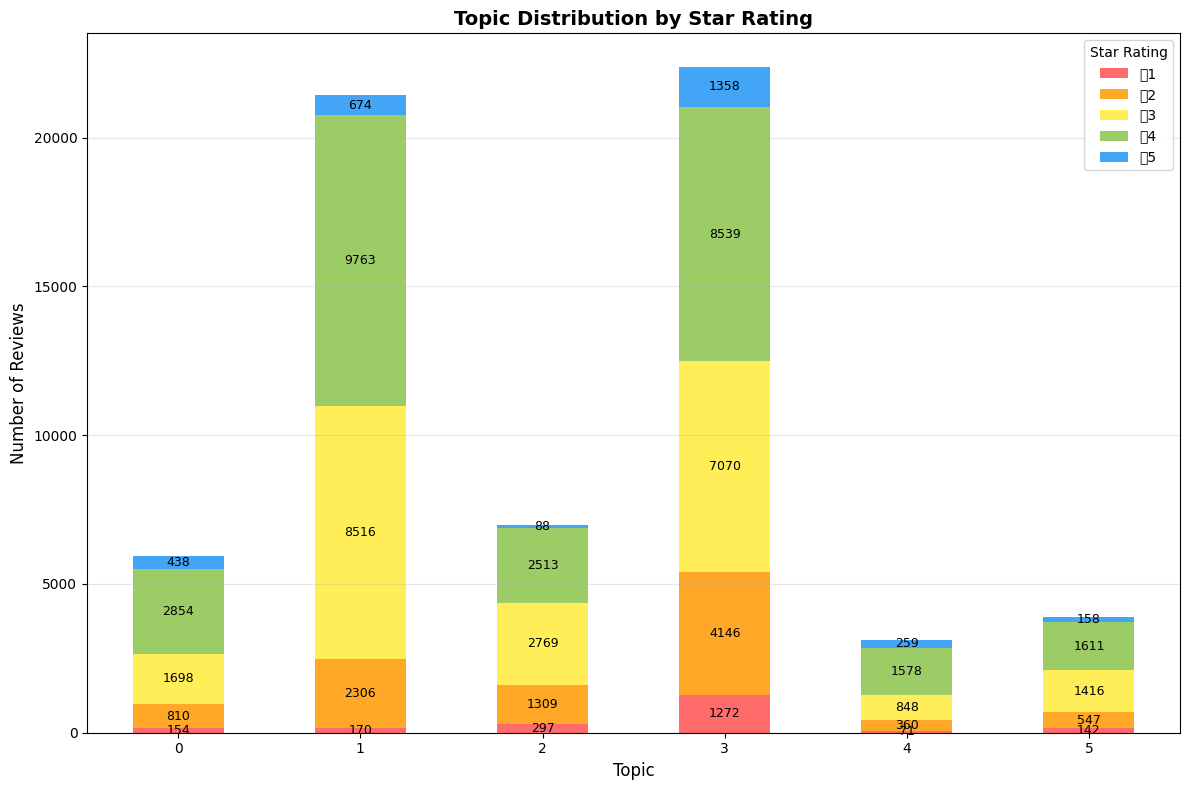


=== Topic Analysis Summary ===
Topic 0: 3.44 ± 0.91 stars (5954 reviews)
Topic 1: 3.40 ± 0.75 stars (21429 reviews)
Topic 2: 3.11 ± 0.87 stars (6976 reviews)
Topic 3: 3.20 ± 1.00 stars (22385 reviews)
Topic 4: 3.51 ± 0.89 stars (3116 reviews)
Topic 5: 3.28 ± 0.89 stars (3874 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_31053/2055396898.py:177: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


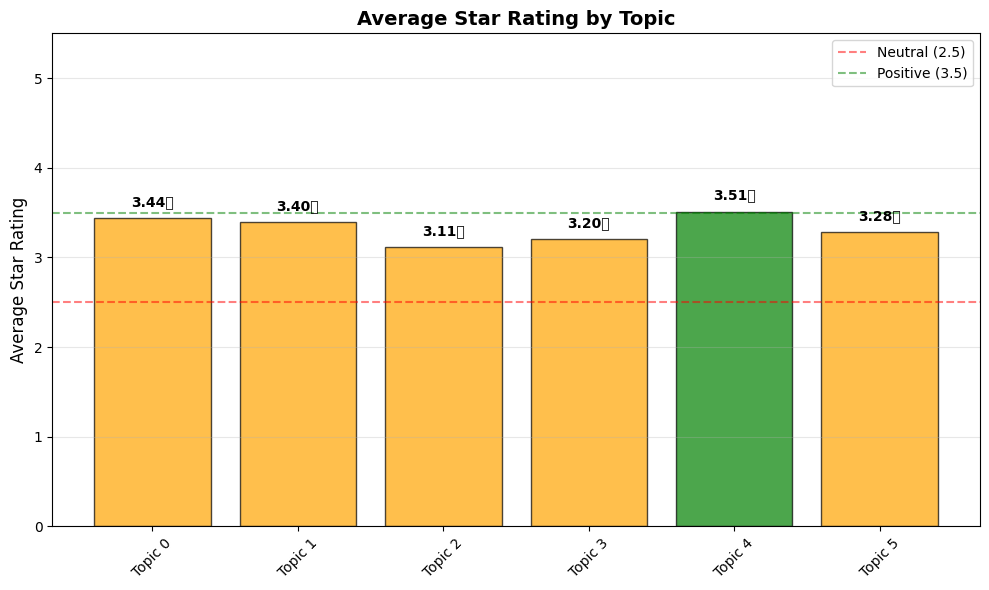

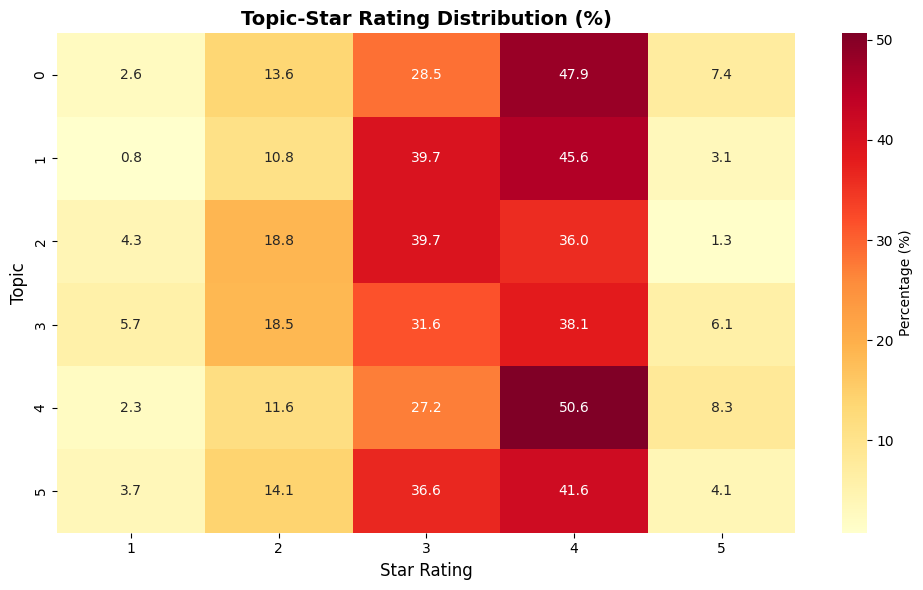

(                   business_id                           name  \
 0       Pns2l4eNsfO8kk83dixA6A       Abby Rappoport, LAC, CMQ   
 3       MTSW4McQd7CbVtyjqoe9mw             St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA       Perkiomen Valley Brewery   
 5       CF33F8-E6oudUQ46HnavjQ                 Sonic Drive-In   
 8       k0hlBqXX-Bt0vf1op7Jr1w          Tsevi's Pub And Grill   
 ...                        ...                            ...   
 150325  l9eLGG9ZKpLJzboZq-9LRQ                           Wawa   
 150327  cM6V90ExQD6KMSU3rRB5ZA              Dutch Bros Coffee   
 150328  1jx1sfgjgVg0nM6n3p0xWA           Savaya Coffee Market   
 150336  WnT9NIzQgLlILjPT0kEcsQ  Adelita Taqueria & Restaurant   
 150339  2O2K6SXPWv56amqxCECd4w                   The Plum Pit   
 
                        address             city state postal_code   latitude  \
 0       1616 Chapala St, Ste 2    Santa Barbara    CA       93101  34.426679   
 3                  935 Race St     Philadel

In [34]:
comprehensive_topic_analysis(filtered_data, n_topics=6)